In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns

In [2]:
import sqlite3
import pandas as pd
from pathlib import Path


def load_db(db_path):
    """Load runs and results tables from SQLite database."""
    db_path = Path(db_path)
    if not db_path.exists():
        raise FileNotFoundError(f"Database not found: {db_path}")
    
    with sqlite3.connect(db_path) as conn:
        runs = pd.read_sql_query("SELECT * FROM runs", conn)
        results = pd.read_sql_query("SELECT * FROM results", conn)
    
    return runs, results


def merge_runs_results(runs, results):
    """Join runs and results tables on run_id."""
    merged = results.merge(runs, on="run_id", how="left")
    return merged

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ENGINE_ORDER = ['naive', 'id', 'priority-id']


def load_and_merge_db(db_path):
    runs, results = load_db(db_path)
    merged = merge_runs_results(runs, results)
    return runs, results, merged


def print_summary_table(merged, title):
    """Print a summary table of engine counts by status."""
    status_summary = []
    for engine_name in ENGINE_ORDER:
        engine_data = merged[merged['engine'] == engine_name]
        decided = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        total = len(engine_data)
        status_summary.append({
            'Engine': engine_name,
            'Decided': decided,
            'Timeout': timeout,
            'Unknown': unknown,
            'Total': total
        })

    summary_df = pd.DataFrame(status_summary)
    print(f"\n{title}")
    print("=" * 70)
    print(summary_df.to_string(index=False))
    print("=" * 70)
    return summary_df


def _build_status_pivot(merged):
    status_summary = (
        merged[merged['engine'].isin(ENGINE_ORDER)]
        .groupby(['engine', 'status'])
        .size()
        .reset_index(name='count')
    )
    pivot = (
        status_summary.pivot(index='engine', columns='status', values='count')
        .fillna(0)
        .astype(int)
        .reindex(ENGINE_ORDER)
    )
    return pivot


def _build_result_type_summary(merged):
    status_summary = []
    for engine_name in ENGINE_ORDER:
        engine_data = merged[merged['engine'] == engine_name]
        decided = len(engine_data[engine_data['status'].isin(['provable', 'not_provable'])])
        timeout = len(engine_data[engine_data['status'] == 'timeout'])
        unknown = len(engine_data[engine_data['status'] == 'unknown'])
        status_summary.append({
            'Engine': engine_name,
            'Decided': decided  ,
            'Timeout': timeout,
            'Unknown': unknown
        })

    return pd.DataFrame(status_summary)


def _build_common_decided_timing(merged):
    decided = merged[merged['status'].isin(['provable', 'not_provable']) & merged['engine'].isin(ENGINE_ORDER)].copy()
    decided['engine'] = pd.Categorical(decided['engine'], categories=ENGINE_ORDER, ordered=True)
    engines = decided['engine'].dropna().unique()
    if len(engines) == 0:
        return pd.DataFrame(), 'No decided rows available for timing comparison.'

    common_problems = (
        decided.groupby('problem_id')['engine'].nunique()
        .pipe(lambda counts: counts[counts == len(ENGINE_ORDER)].index)
    )
    common_decided = decided[decided['problem_id'].isin(common_problems)].copy()
    plot_df = common_decided[['problem_id', 'engine', 'elapsed_ms']].copy()
    plot_df['engine'] = pd.Categorical(plot_df['engine'], categories=ENGINE_ORDER, ordered=True)
    return plot_df, None


def _render_dataset_overview(summary_pivot, summary_df, plot_df, title, dataset_name, figure_format='pdf'):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    fig.suptitle(f"{title} Overview", fontsize=16, fontweight='bold')

    summary_pivot = summary_pivot.reindex(ENGINE_ORDER).fillna(0).astype(int)
    summary_pivot.plot(kind='bar', ax=axes[0])
    axes[0].grid()
    axes[0].set_title('Results by Engine and Status', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Engine', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=0)

    summary_df = summary_df.set_index('Engine').reindex(ENGINE_ORDER).reset_index()
    summary_df_melted = summary_df.melt(id_vars='Engine', var_name='Status', value_name='Count')
    sns.barplot(data=summary_df_melted, x='Engine', y='Count', hue='Status', ax=axes[1], palette='Set2', order=ENGINE_ORDER)
    axes[1].grid()
    axes[1].set_title('Decided vs Timeout vs Unknown', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Engine', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].legend(title='Status', fontsize=9)

    if plot_df.empty:
        axes[2].text(0.5, 0.5, 'No decided rows available for timing comparison.', ha='center', va='center')
        axes[2].set_axis_off()
    else:
        sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)
        sns.stripplot(data=plot_df, x='engine', y='elapsed_ms', color='black', alpha=0.3, size=3, ax=axes[2], order=ENGINE_ORDER)
        axes[2].set_yscale('log')
        axes[2].grid()
        axes[2].set_title('Time to Conclusion on Common Decided Problems', fontsize=13, fontweight='bold')
        axes[2].set_xlabel('Engine', fontsize=12)
        axes[2].set_ylabel('Elapsed ms (log scale)', fontsize=12)
        axes[2].tick_params(axis='x', rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    figures_dir = Path("../report/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / f"{dataset_name}_overview.{figure_format}"
    plt.savefig(figure_path, format=figure_format)
    plt.show()


def analyze_dataset(db_path_or_df, dataset_name, title_prefix, output_dir=Path("../report/figures/tabulated"), save_csvs=None, figure_format='pdf'):
    """
    Load a database or use provided dataframe, perform full analysis, generate plots, and optionally save CSVs.
    
    Parameters:
    -----------
    db_path_or_df : str, Path, or pd.DataFrame
        Path to the SQLite database file, or a pre-loaded merged dataframe
    dataset_name : str
        Short name for the dataset (e.g., 'tptp_provable', 'bushy')
    title_prefix : str
        Descriptive prefix for titles (e.g., 'TPTP Provable Results')
    output_dir : str or Path
        Directory where CSV files will be saved
    save_csvs : iterable[str] | None
        Names of CSV outputs to save. Defaults to the plot-backed CSVs only.
        Supported values: 'summary_table', 'engine_status_pivot', 'result_type_summary', 'common_decided_timing', 'results'
    figure_format : str
        Figure format to write, for example 'svg' or 'pdf'
    """
    if save_csvs is None:
        save_csvs = {'engine_status_pivot', 'result_type_summary', 'common_decided_timing'}
    else:
        save_csvs = set(save_csvs)

    if isinstance(db_path_or_df, pd.DataFrame):
        merged = db_path_or_df.copy()
        print('Using provided dataframe:')
        print(f'  Merged: {len(merged)} rows')
    else:
        candidate_paths = [Path(f'analysis/{db_path_or_df}'), Path(db_path_or_df)]
        redecided_path = next((path for path in candidate_paths if path.exists()), candidate_paths[0])
        runs, results, merged = load_and_merge_db(redecided_path)
        print(f'{redecided_path} loaded:')
        print(f'  Runs: {len(runs)} rows')
        print(f'  Results: {len(results)} rows')
        print(f'  Merged: {len(merged)} rows')
    print()

    summary_df = print_summary_table(merged, f'{title_prefix} Summary')
    status_pivot = _build_status_pivot(merged)
    result_type_summary = _build_result_type_summary(merged)
    plot_df, timing_msg = _build_common_decided_timing(merged)
    if timing_msg:
        print(timing_msg)

    _render_dataset_overview(status_pivot, summary_df, plot_df, title_prefix, dataset_name, figure_format=figure_format)

    results_dir = Path(output_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    saved_files = []
    if 'summary_table' in save_csvs:
        summary_df.to_csv(results_dir / f"{dataset_name}_summary_table.csv", index=False)
        saved_files.append(f"{dataset_name}_summary_table.csv")
    if 'engine_status_pivot' in save_csvs:
        status_pivot.to_csv(results_dir / f"{dataset_name}_engine_status_pivot.csv")
        saved_files.append(f"{dataset_name}_engine_status_pivot.csv")
    if 'result_type_summary' in save_csvs:
        result_type_summary.to_csv(results_dir / f"{dataset_name}_result_type_summary.csv", index=False)
        saved_files.append(f"{dataset_name}_result_type_summary.csv")
    if 'common_decided_timing' in save_csvs:
        plot_df.to_csv(results_dir / f"{dataset_name}_common_decided_timing.csv", index=False)
        saved_files.append(f"{dataset_name}_common_decided_timing.csv")
    if 'results' in save_csvs:
        combined_results = summary_df.copy()
        combined_results['Dataset'] = dataset_name
        combined_results = combined_results[['Dataset', 'Engine', 'Decided', 'Timeout', 'Unknown', 'Total']]
        combined_results = combined_results.set_index('Engine').reindex(ENGINE_ORDER).reset_index()
        combined_results.to_csv(results_dir / f"{dataset_name}_results.csv", index=False)
        saved_files.append(f"{dataset_name}_results.csv")

    print(f"\n{'Output Summary':^70}")
    print("=" * 70)
    print(f"Output Directory: {results_dir.resolve()}")
    print(f"Dataset: {dataset_name}")
    if saved_files:
        print('Files Saved:')
        for saved_file in saved_files:
            print(f'  - {saved_file}')
    else:
        print('Files Saved: none')
    print(f"Figure: ../report/figures/{dataset_name}_overview.{figure_format}")
    print("=" * 70)

    return merged, summary_df, status_pivot, result_type_summary, plot_df

tptp-provable-results.db loaded:
  Runs: 3 rows
  Results: 2211 rows
  Merged: 2211 rows


TPTP Provable Results Summary
     Engine  Decided  Timeout  Unknown  Total
      naive      152      573       12    737
         id      199      526       12    737
priority-id      209      516       12    737


C:\Users\madel\AppData\Local\Temp\ipykernel_22952\3504830525.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


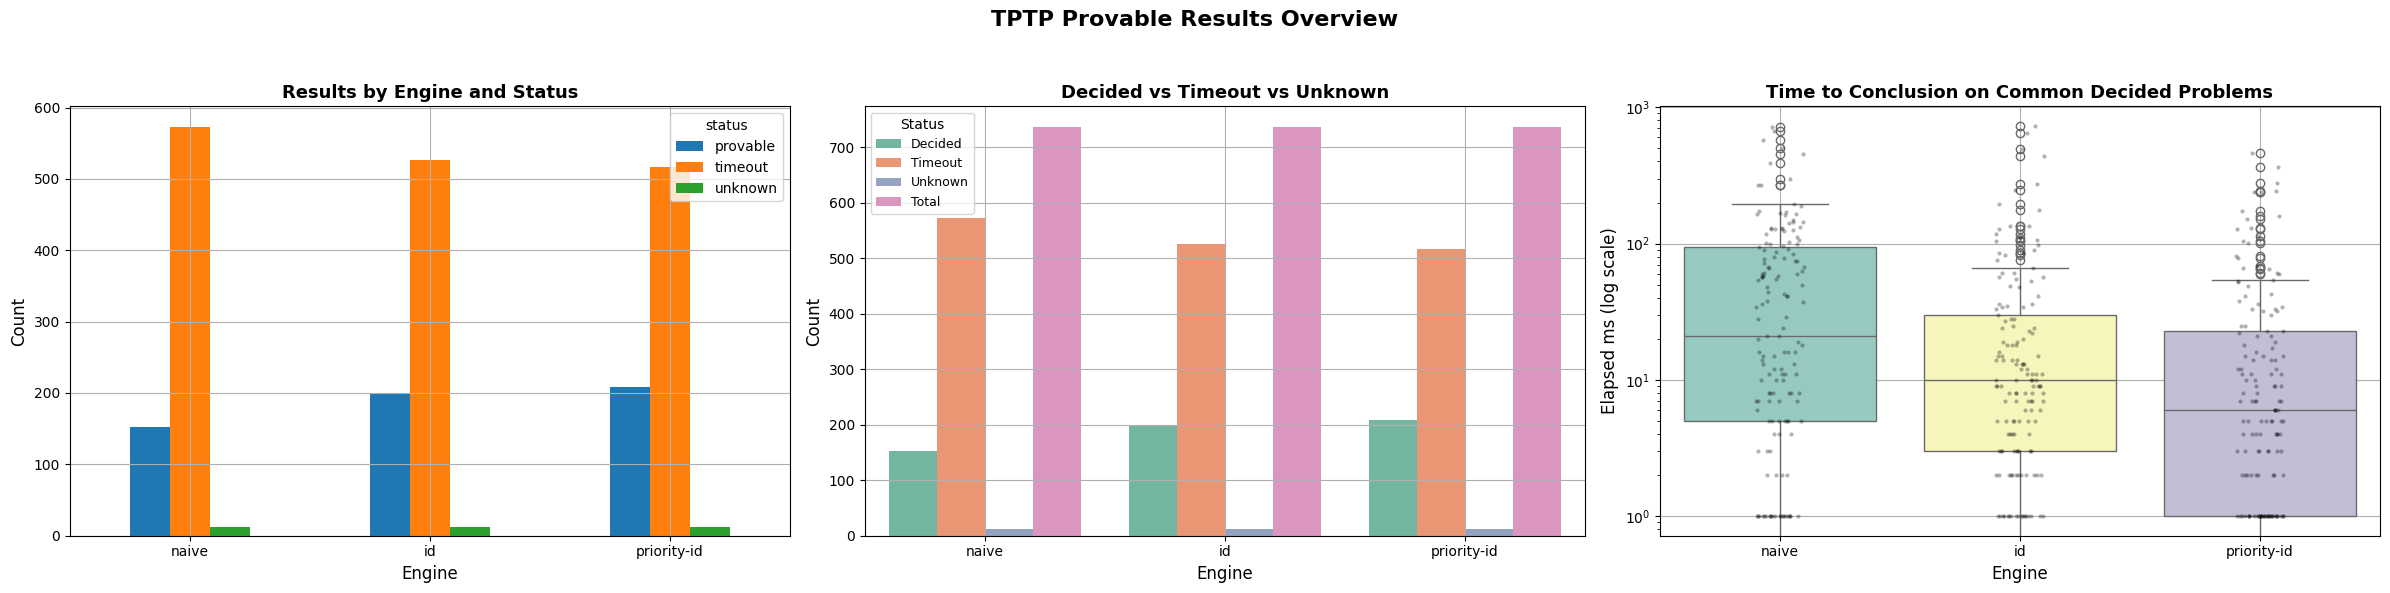


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_provable
Files Saved:
  - tptp_provable_engine_status_pivot.csv
  - tptp_provable_result_type_summary.csv
  - tptp_provable_common_decided_timing.csv
Figure: ../report/figures/tptp_provable_overview.pdf
tptp-unprovable-results.db loaded:
  Runs: 3 rows
  Results: 453 rows
  Merged: 453 rows


TPTP Unprovable Results Summary
     Engine  Decided  Timeout  Unknown  Total
      naive        4      143        4    151
         id        4      143        4    151
priority-id        4      142        5    151


C:\Users\madel\AppData\Local\Temp\ipykernel_22952\3504830525.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


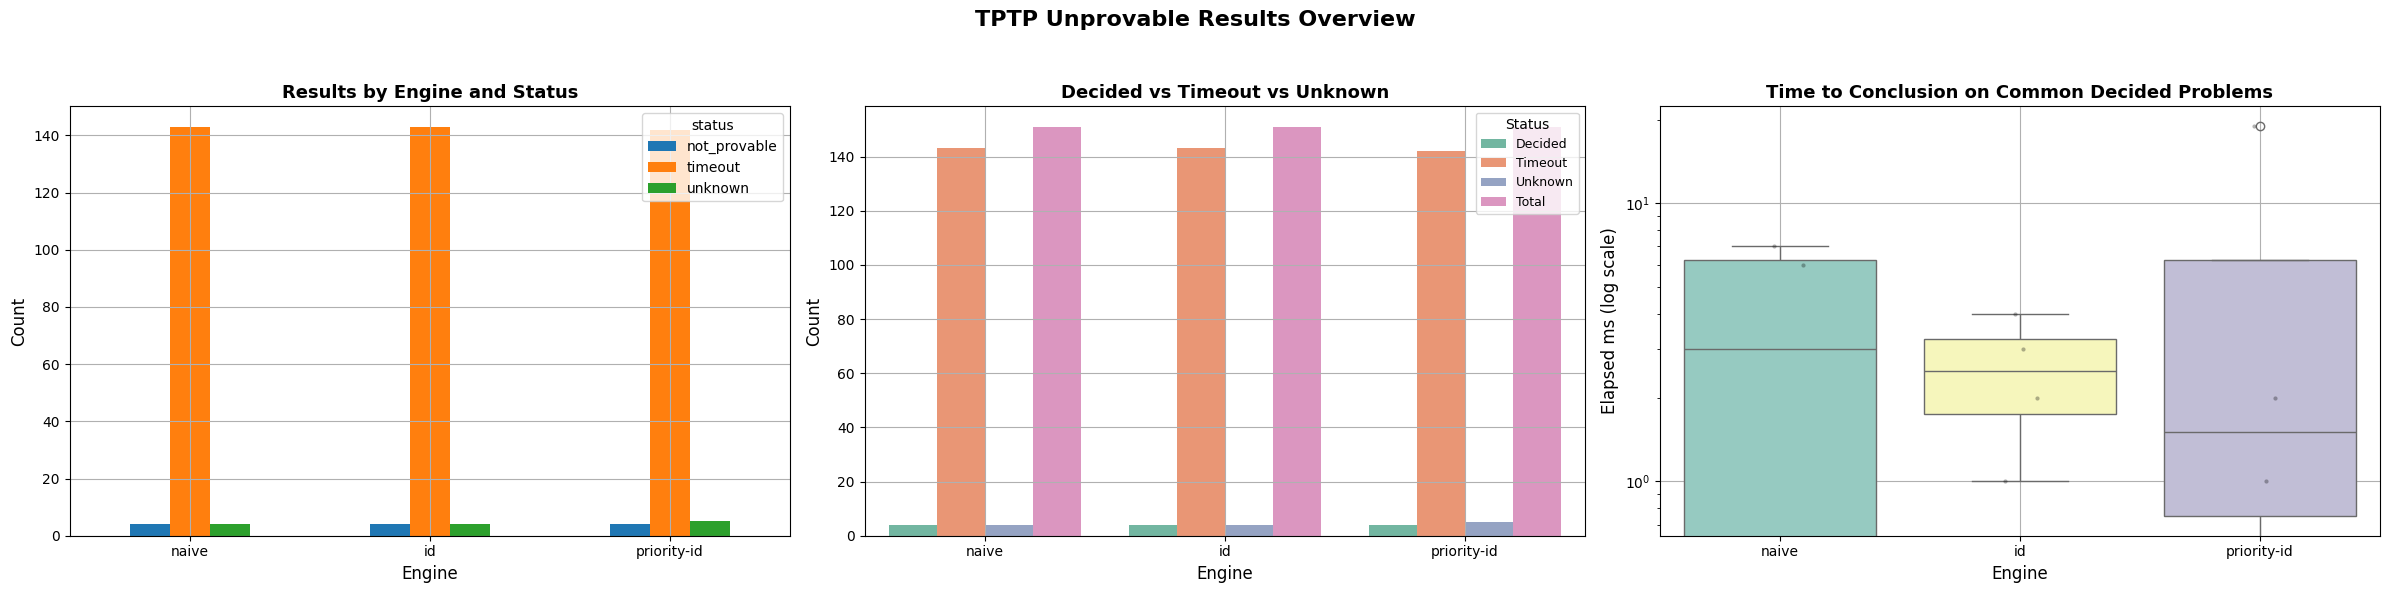


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_unprovable
Files Saved:
  - tptp_unprovable_engine_status_pivot.csv
  - tptp_unprovable_result_type_summary.csv
  - tptp_unprovable_common_decided_timing.csv
Figure: ../report/figures/tptp_unprovable_overview.pdf
Using provided dataframe:
  Merged: 2664 rows


TPTP Combined (Provable + Unprovable) Summary
     Engine  Decided  Timeout  Unknown  Total
      naive      156      716       16    888
         id      203      669       16    888
priority-id      213      658       17    888


C:\Users\madel\AppData\Local\Temp\ipykernel_22952\3504830525.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


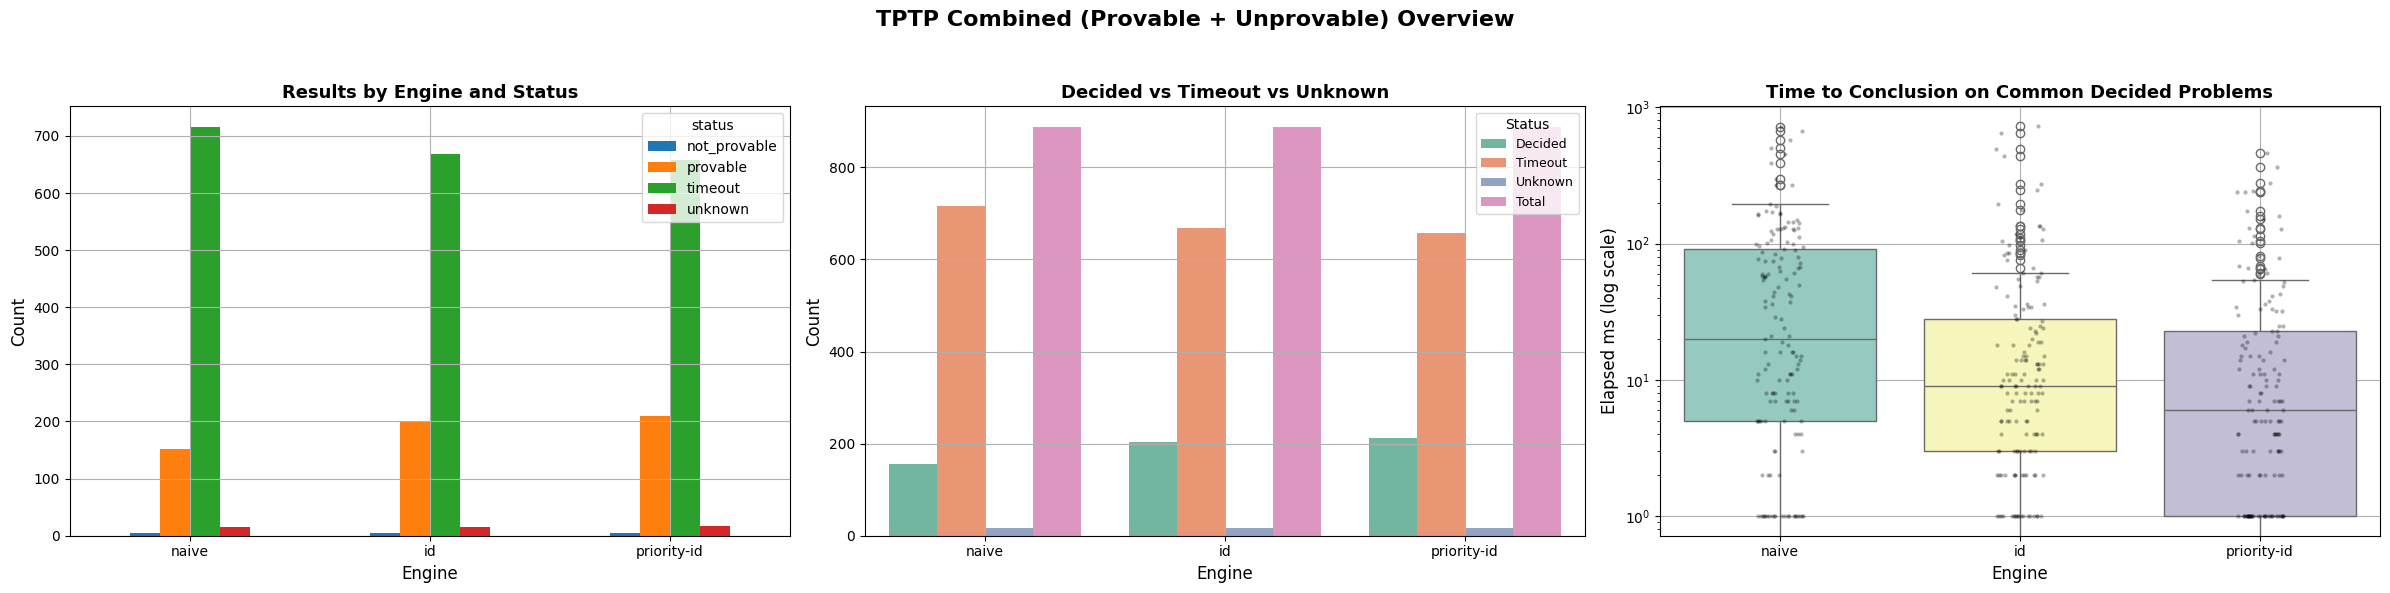


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: tptp_combined
Files Saved:
  - tptp_combined_engine_status_pivot.csv
  - tptp_combined_result_type_summary.csv
  - tptp_combined_common_decided_timing.csv
Figure: ../report/figures/tptp_combined_overview.pdf
generated-results.db loaded:
  Runs: 3 rows
  Results: 606 rows
  Merged: 606 rows


Synthetic Results Summary
     Engine  Decided  Timeout  Unknown  Total
      naive       26      168        8    202
         id       39      155        8    202
priority-id       42      152        8    202


C:\Users\madel\AppData\Local\Temp\ipykernel_22952\3504830525.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


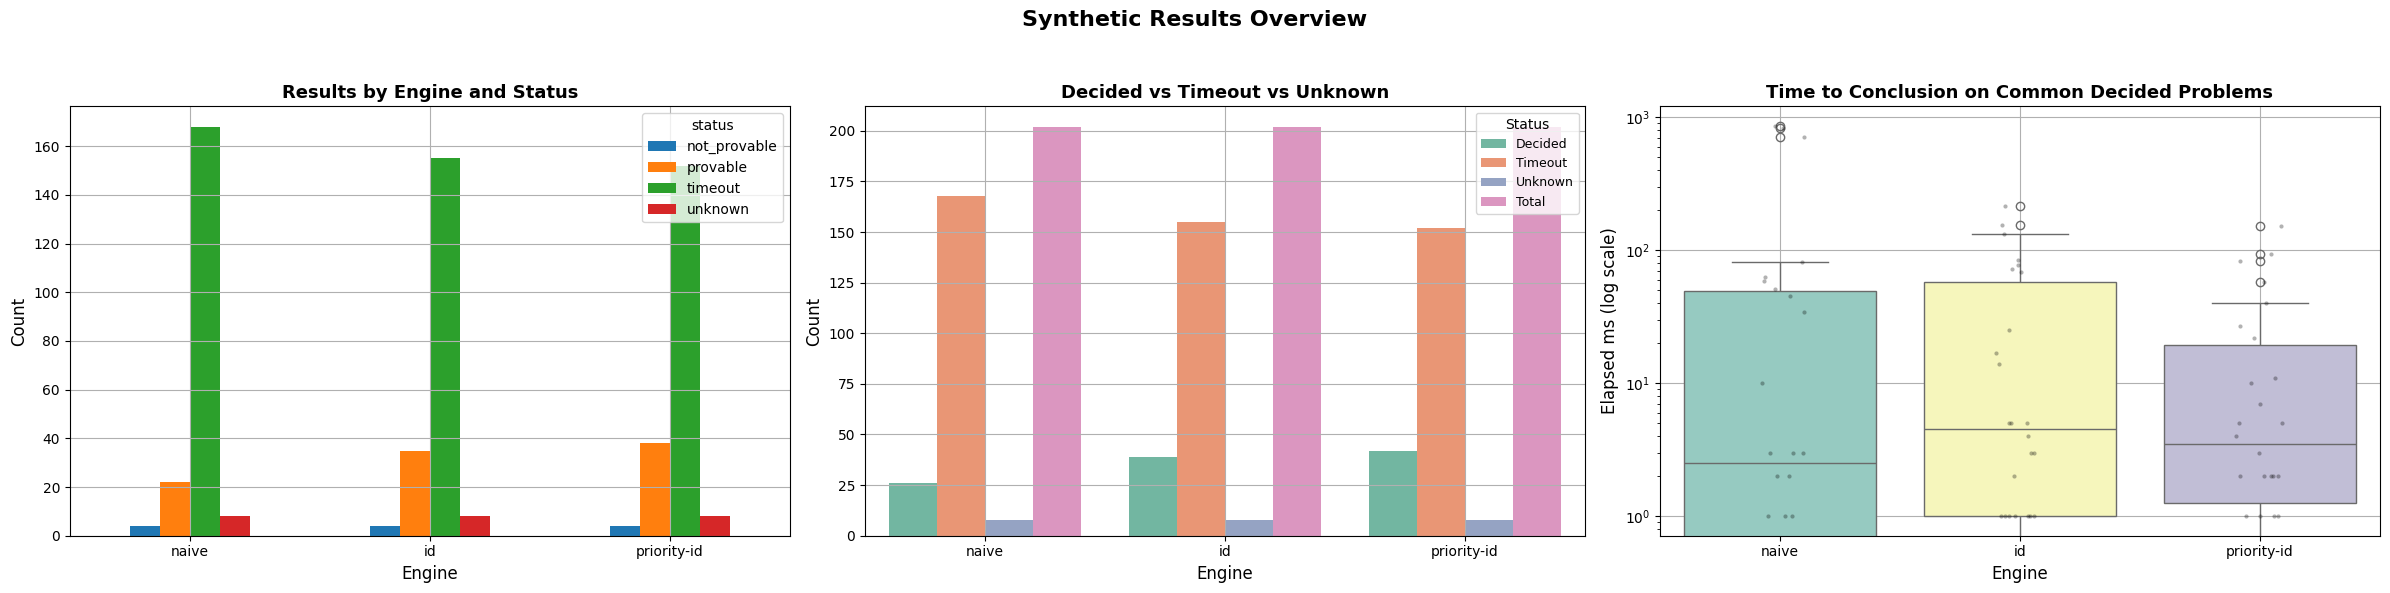


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: generated
Files Saved:
  - generated_engine_status_pivot.csv
  - generated_result_type_summary.csv
  - generated_common_decided_timing.csv
Figure: ../report/figures/generated_overview.pdf
folio-results.db loaded:
  Runs: 3 rows
  Results: 840 rows
  Merged: 840 rows


FOLIO Results Summary
     Engine  Decided  Timeout  Unknown  Total
      naive       57      204       19    280
         id       57      198       25    280
priority-id       66      204       10    280


C:\Users\madel\AppData\Local\Temp\ipykernel_22952\3504830525.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='engine', y='elapsed_ms', palette='Set3', ax=axes[2], order=ENGINE_ORDER)


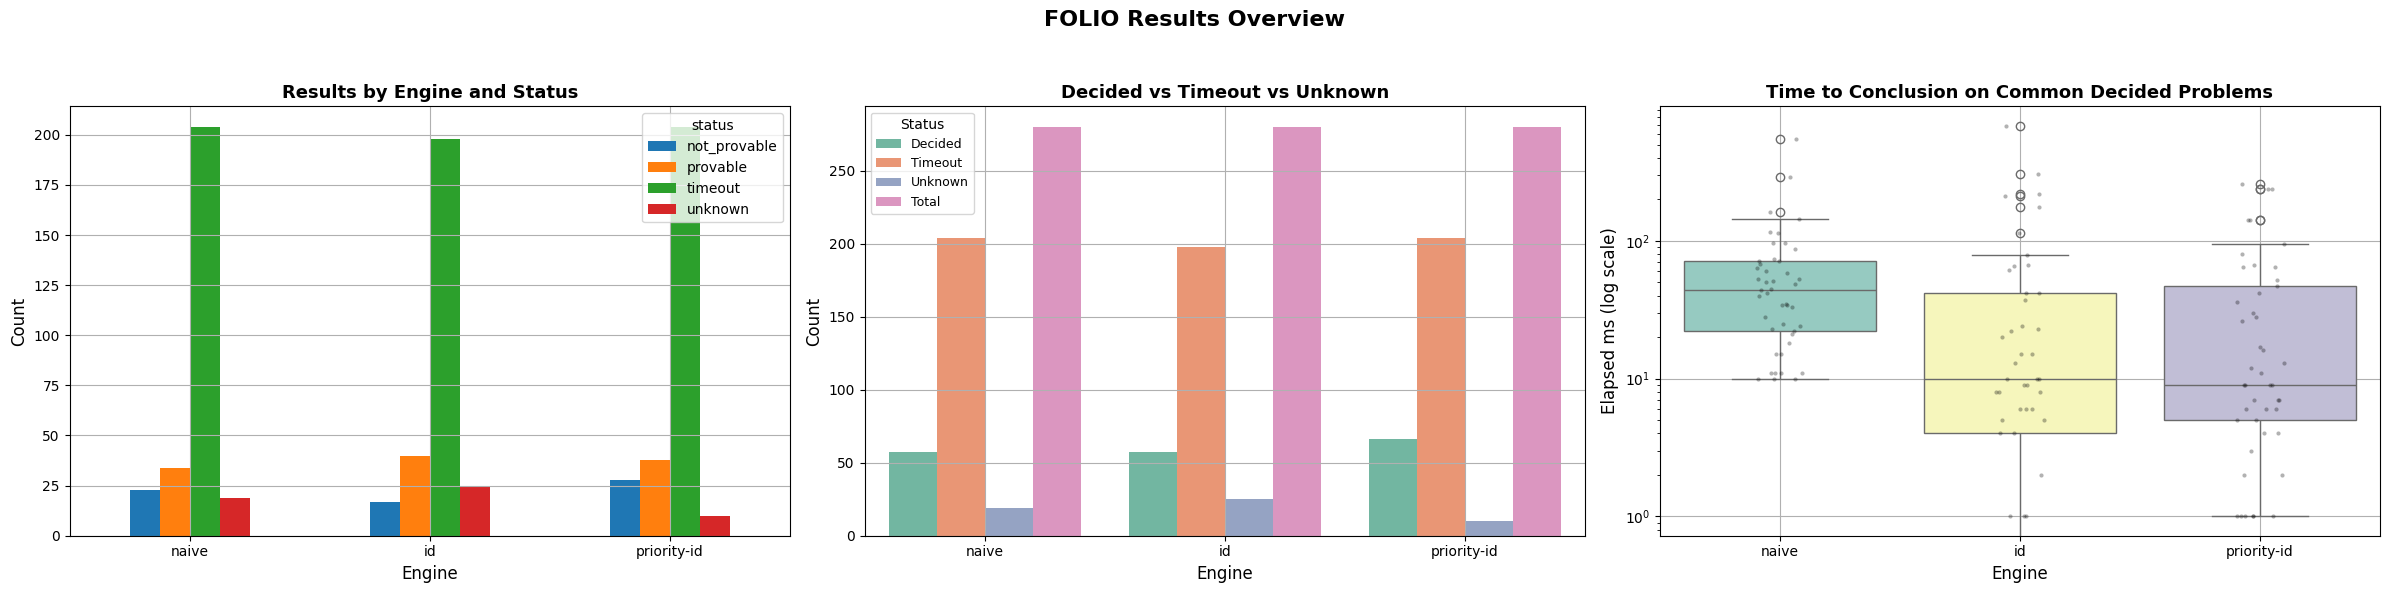


                            Output Summary                            
Output Directory: C:\Users\madel\source\repos\logic-assignment\report\figures\tabulated
Dataset: folio
Files Saved:
  - folio_engine_status_pivot.csv
  - folio_result_type_summary.csv
  - folio_common_decided_timing.csv
Figure: ../report/figures/folio_overview.pdf


In [5]:
# Analyze TPTP Provable
tptp_prov_merged, tptp_prov_summary, tptp_prov_status_pivot, tptp_prov_result_types, tptp_prov_timing = analyze_dataset(
    'tptp-provable-results.db',
    'tptp_provable',
    'TPTP Provable Results'
)

# Analyze TPTP Unprovable
tptp_unprv_merged, tptp_unprv_summary, tptp_unprv_status_pivot, tptp_unprv_result_types, tptp_unprv_timing = analyze_dataset(
    'tptp-unprovable-results.db',
    'tptp_unprovable',
    'TPTP Unprovable Results'
)
# Combine TPTP Provable and Unprovable results
tptp_combined_df = pd.concat([tptp_prov_merged, tptp_unprv_merged], ignore_index=True)

tptp_combined_merged, tptp_combined_summary, tptp_combined_status_pivot, tptp_combined_result_types, tptp_combined_timing = analyze_dataset(
    tptp_combined_df,
    'tptp_combined',
    'TPTP Combined (Provable + Unprovable)'
)

# Analyze Synthetically Generated
gen_merged, gen_summary, gen_status_pivot, gen_result_types, gen_timing = analyze_dataset(
    'generated-results.db',
    'generated',
    'Synthetic Results'
)
-

# Analyze FOLIO
folio_merged, folio_summary, folio_status_pivot, folio_result_types, folio_timing = analyze_dataset(
    'folio-results.db',
    'folio',
    'FOLIO Results'
)

In [ ]:
# Combine all datasets: TPTP Combined + Generated + FOLIO
all_datasets_df = pd.concat([tptp_combined_merged, gen_merged, folio_merged], ignore_index=True)

all_combined_merged, all_combined_summary, all_combined_status_pivot, all_combined_result_types, all_combined_timing = analyze_dataset(
    all_datasets_df,
    'all_combined',
    'All Datasets Combined (TPTP + Generated + FOLIO)'
)

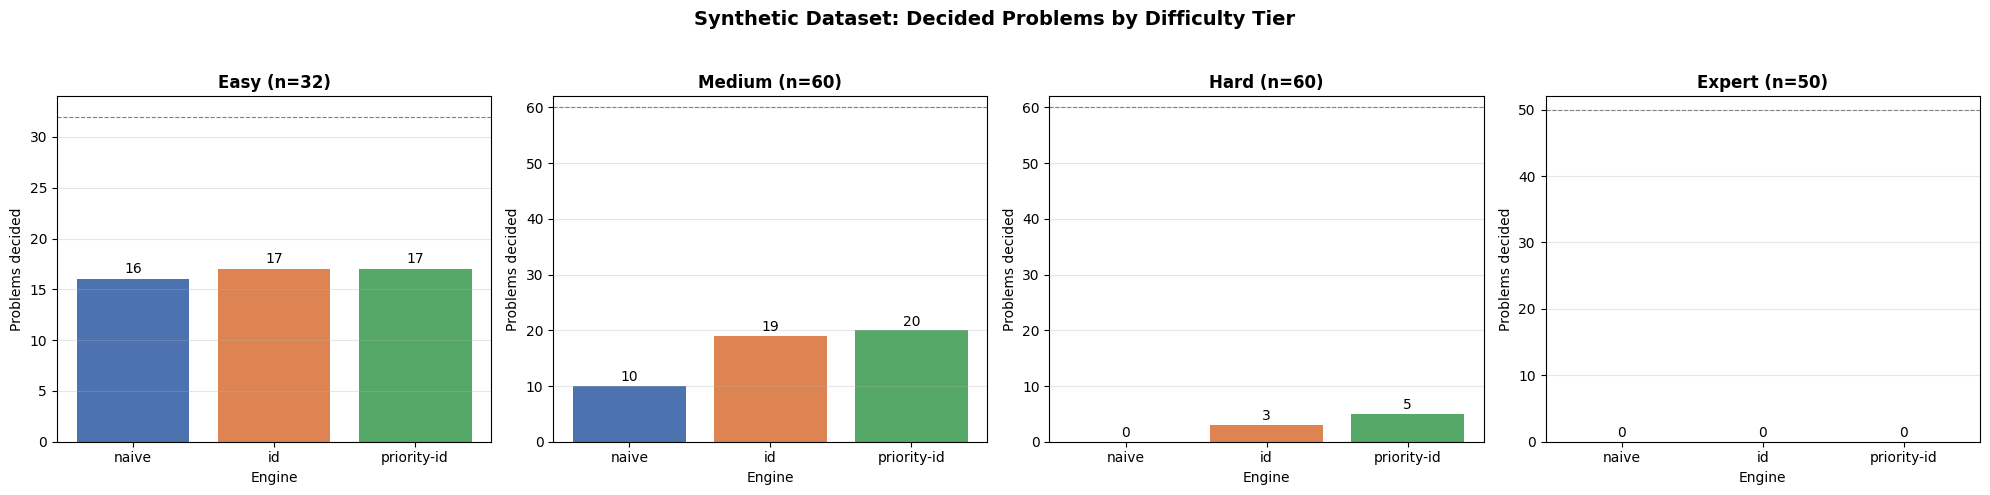

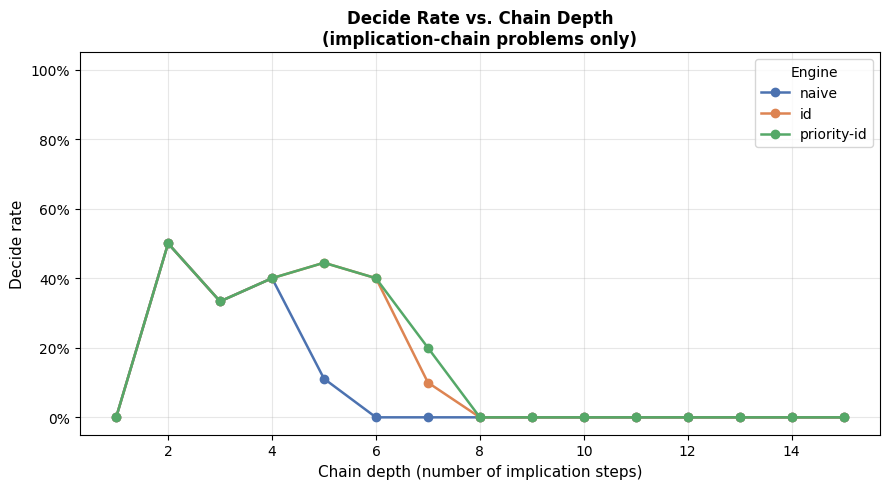

Tier breakdown (decided / total):
Engine         Easy          Medium        Hard          Expert        
naive          16/32         10/60         0/60         0/50         
id             17/32         19/60         3/60         0/50         
priority-id    17/32         20/60         5/60         0/50         

Decided by problem family:
  implication_chain     : naive=11/119  id=19/119  priority-id=20/119
  syllogism             : naive=5/24  id=9/24  priority-id=11/24
  transitivity          : naive=0/43  id=0/43  priority-id=0/43
  quantifier_alt        : naive=10/16  id=11/16  priority-id=11/16


In [25]:
# Synthetic dataset: tier breakdown and chain-depth analysis
import re
import glob
import os
from pathlib import Path

TIER_ORDER = ['easy', 'medium', 'hard', 'expert']


def parse_synthetic_problem(path):
    with open(path) as f:
        content = f.read()
    steps = len(re.findall(r'fof\(step\d+', content))
    distractors = len(re.findall(r'fof\(dist\d+', content))
    if re.search(r'rel\(', content):
        family = 'transitivity'
    elif re.search(r'entity|organism|teacher', content):
        family = 'syllogism'
    elif steps > 0:
        family = 'implication_chain'
    else:
        family = 'quantifier_alt'
    return steps, distractors, family


rows = []
for path in glob.glob('../AI_generated/*.p'):
    name = os.path.basename(path).replace('.p', '')
    tier = name.rsplit('_', 1)[0]
    steps, dist, family = parse_synthetic_problem(path)
    rows.append({'problem_id': name, 'tier': tier, 'chain_depth': steps, 'distractors': dist, 'family': family})
meta_df = pd.DataFrame(rows)

syn_merged = ai_gen_merged.merge(meta_df, on='problem_id')
syn_merged['tier'] = pd.Categorical(syn_merged['tier'], categories=TIER_ORDER, ordered=True)
syn_merged['engine'] = pd.Categorical(syn_merged['engine'], categories=ENGINE_ORDER, ordered=True)

palette = {'naive': '#4C72B0', 'id': '#DD8452', 'priority-id': '#55A868'}

# Figure 1: decided count per tier per engine
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
fig.suptitle('Synthetic Dataset: Decided Problems by Difficulty Tier', fontsize=14, fontweight='bold')

for ax, tier in zip(axes, TIER_ORDER):
    tier_df = syn_merged[syn_merged['tier'] == tier]
    total = tier_df['problem_id'].nunique()
    decided_counts = (
        tier_df[tier_df['status'].isin(['provable', 'not_provable'])]
        .groupby('engine', observed=True)['problem_id'].count()
        .reindex(ENGINE_ORDER, fill_value=0)
        .reset_index()
    )
    decided_counts.columns = ['engine', 'decided']
    bars = ax.bar(decided_counts['engine'], decided_counts['decided'],
                  color=[palette[e] for e in decided_counts['engine']])
    ax.set_title(f'{tier.capitalize()} (n={total})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Engine', fontsize=10)
    ax.set_ylabel('Problems decided', fontsize=10)
    ax.set_ylim(0, total + 2)
    ax.axhline(total, color='grey', linestyle='--', linewidth=0.8, label='total')
    ax.tick_params(axis='x', rotation=0)
    for bar, val in zip(bars, decided_counts['decided']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
figures_dir = Path('../report/figures')
plt.savefig(figures_dir / 'ai_generated_tier_breakdown.pdf', format='pdf')
plt.show()

# Figure 2: decide rate vs chain depth (implication-chain problems only)
impl_df = syn_merged[syn_merged['family'] == 'implication_chain'].copy()
depth_decide = (
    impl_df.groupby(['engine', 'chain_depth'], observed=True)
    .apply(lambda g: g['status'].isin(['provable', 'not_provable']).mean(), include_groups=False)
    .reset_index(name='decide_rate')
)
depth_decide['engine'] = pd.Categorical(depth_decide['engine'], categories=ENGINE_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(9, 5))
for engine in ENGINE_ORDER:
    sub = depth_decide[depth_decide['engine'] == engine].sort_values('chain_depth')
    ax.plot(sub['chain_depth'], sub['decide_rate'], marker='o', label=engine,
            color=palette[engine], linewidth=1.8)
ax.set_xlabel('Chain depth (number of implication steps)', fontsize=11)
ax.set_ylabel('Decide rate', fontsize=11)
ax.set_title('Decide Rate vs. Chain Depth\n(implication-chain problems only)', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Engine', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'ai_generated_depth_decide_rate.pdf', format='pdf')
plt.show()

# Summary
print('Tier breakdown (decided / total):')
header = f"{'Engine':<15}" + ''.join(f'{t.capitalize():<14}' for t in TIER_ORDER)
print(header)
for engine in ENGINE_ORDER:
    row = f'{engine:<15}'
    for tier in TIER_ORDER:
        sub = syn_merged[(syn_merged['engine'] == engine) & (syn_merged['tier'] == tier)]
        decided = int(sub['status'].isin(['provable', 'not_provable']).sum())
        total = sub['problem_id'].nunique()
        row += f'{decided}/{total:<11}'
    print(row)

print()
print('Decided by problem family:')
for family in ['implication_chain', 'syllogism', 'transitivity', 'quantifier_alt']:
    fam_df = syn_merged[syn_merged['family'] == family]
    total = fam_df['problem_id'].nunique()
    counts = {e: int(fam_df[(fam_df['engine']==e) & fam_df['status'].isin(['provable','not_provable'])]['problem_id'].count())
              for e in ENGINE_ORDER}
    print(f"  {family:<22}: naive={counts['naive']}/{total}  id={counts['id']}/{total}  priority-id={counts['priority-id']}/{total}")